
# Seminar 4: Temporal Fusion Transformer mit `get_stallion_data()`

Dieses Notebook konzentriert sich nur noch auf den **Temporal Fusion Transformer (TFT)**. Als Datengrundlage bleibt der offizielle Example-Datensatz `get_stallion_data()` aus `pytorch-forecasting` erhalten.

Warum `stallion` hier gut zum TFT passt:

- viele parallele Reihen (`agency` x `sku`)
- **statische Merkmale** pro Reihe
- mehrere **bekannte Zukunftsvariablen** wie Preis, Discount, Temperatur und Kalendermerkmale
- damit eine typische Business-Situation fuer TFT



## Ablauf

1. Stallion-Datensatz laden und auf einen gut trainierbaren Ausschnitt reduzieren
2. `TimeSeriesDataSet` fuer den TFT aufbauen
3. TFT trainieren
4. Vorhersagen fuer den letzten Horizont aller Reihen auswerten

**Hinweis**

Das Notebook verwendet einen kompakten, aber deutlich groesseren Ausschnitt als vorher: `48` Reihen mit voller Historie von `60` Monaten. So bleibt das Beispiel auf CPU lauffaehig, ohne den TFT auf nur sehr wenige Beispiele zu beschraenken.


In [1]:

import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import torch
import lightning as L

from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.data.examples import get_stallion_data
from pytorch_forecasting.metrics import QuantileLoss

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
L.seed_everything(SEED)


def mae(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(np.abs(y_true - y_pred))


def rmse(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denominator = np.maximum(np.abs(y_true), 1e-6)
    return np.mean(np.abs((y_true - y_pred) / denominator)) * 100


Seed set to 42



## Datengrundlage

Der `stallion`-Datensatz enthaelt monatliche Absatzdaten fuer Getraenkeprodukte. Eine Zeitreihe wird durch die Kombination aus `agency` und `sku` beschrieben.

Fuer dieses Notebook verwenden wir die `48` Reihen mit voller Historie von `60` Monaten und der hoechsten mittleren Absatzmenge. Dadurch bekommt der TFT mehr parallele Trainingsbeispiele als im frueheren Mini-Setup.


In [2]:

raw_df = get_stallion_data().copy()
raw_df["agency"] = raw_df["agency"].astype(str)
raw_df["sku"] = raw_df["sku"].astype(str)
raw_df["date"] = pd.to_datetime(raw_df["date"])
raw_df["time_idx"] = raw_df["date"].dt.year * 12 + raw_df["date"].dt.month
raw_df["time_idx"] -= raw_df["time_idx"].min()
raw_df["month"] = raw_df["date"].dt.strftime("%m")

series_summary = (
    raw_df.groupby(["agency", "sku"], observed=True)["volume"]
    .agg(n_obs="size", mean_volume="mean")
    .reset_index()
)
selected_series = (
    series_summary.query("n_obs == 60")
    .sort_values("mean_volume", ascending=False)
    .head(48)
    .copy()
)
selected_series["series_id"] = selected_series["agency"] + "_" + selected_series["sku"]

model_df = raw_df.merge(
    selected_series[["agency", "sku"]],
    on=["agency", "sku"],
    how="inner",
).copy()
model_df["series_id"] = model_df["agency"] + "_" + model_df["sku"]
model_df = model_df.sort_values(["series_id", "date"]).reset_index(drop=True)

focus_series_id = selected_series.iloc[0]["series_id"]
plot_series = selected_series["series_id"].head(4).tolist()
focus_df = model_df[model_df["series_id"] == focus_series_id].copy().reset_index(drop=True)

print("Raw dataset shape:", raw_df.shape)
print("Model subset shape:", model_df.shape)
print("Date range:", model_df["date"].min().date(), "bis", model_df["date"].max().date())
print("Anzahl Reihen im Modell-Subset:", model_df["series_id"].nunique())

selected_series[["agency", "sku", "series_id", "mean_volume"]].head(10)


Raw dataset shape: (21000, 28)
Model subset shape: (2880, 29)
Date range: 2013-01-01 bis 2017-12-01
Anzahl Reihen im Modell-Subset: 48


,agency,sku,series_id,mean_volume
8,Agency_02,SKU_03,Agency_02_SKU_03,14766.299647
278,Agency_50,SKU_02,Agency_50_SKU_02,12647.808475
26,Agency_05,SKU_01,Agency_05_SKU_01,12595.021300
343,Agency_60,SKU_01,Agency_60_SKU_01,11752.066850
66,Agency_12,SKU_01,Agency_12_SKU_01,11622.589450
108,Agency_20,SKU_02,Agency_20_SKU_02,11400.021225
174,Agency_30,SKU_03,Agency_30_SKU_03,11337.631162
271,Agency_49,SKU_03,Agency_49_SKU_03,10480.216562
17,Agency_03,SKU_03,Agency_03_SKU_03,10183.428543
205,Agency_38,SKU_01,Agency_38_SKU_01,10159.952450


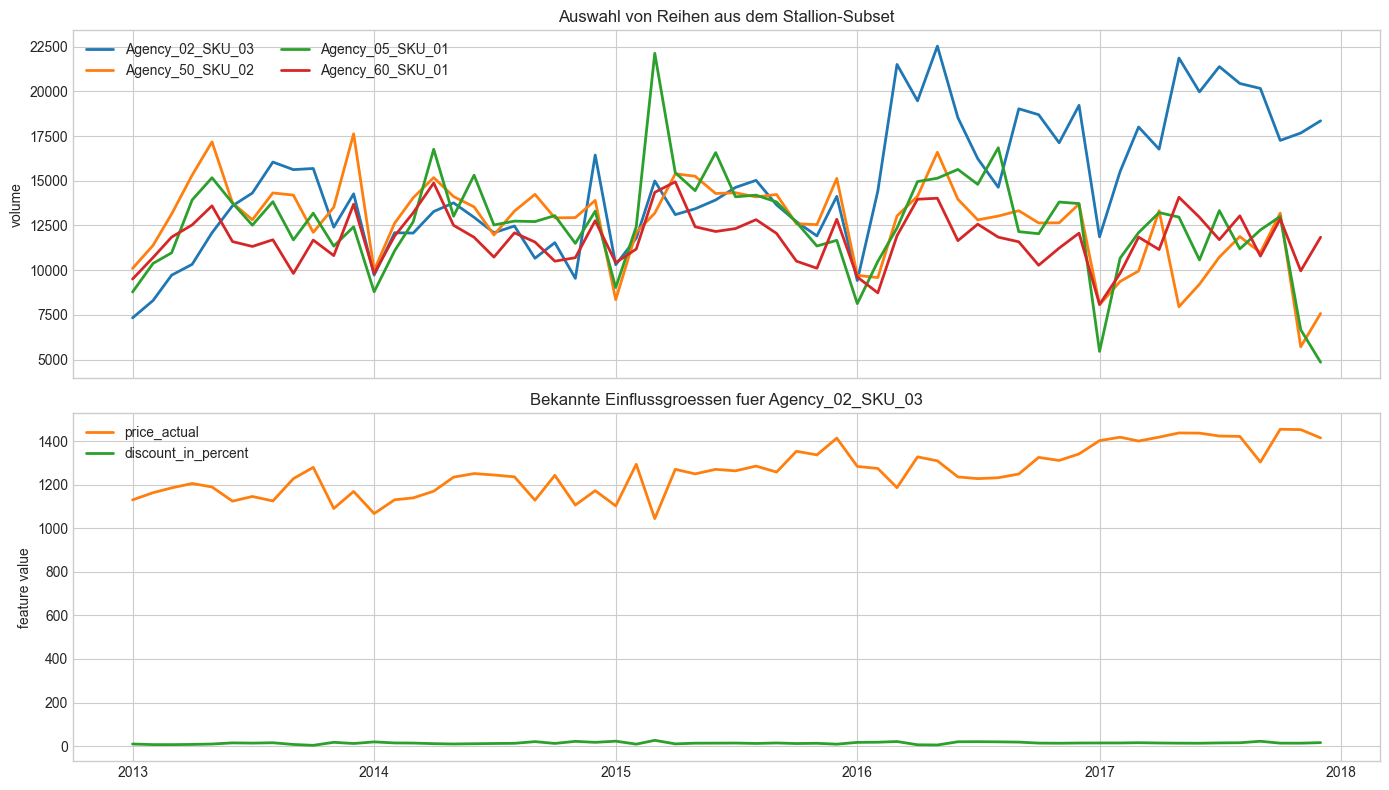

In [3]:

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for series_id in plot_series:
    subset = model_df[model_df["series_id"] == series_id]
    axes[0].plot(subset["date"], subset["volume"], linewidth=2, label=series_id)

axes[0].set_title("Auswahl von Reihen aus dem Stallion-Subset")
axes[0].set_ylabel("volume")
axes[0].legend(ncol=2)

axes[1].plot(focus_df["date"], focus_df["price_actual"], linewidth=2, color="tab:orange", label="price_actual")
axes[1].plot(
    focus_df["date"],
    focus_df["discount_in_percent"],
    linewidth=2,
    color="tab:green",
    label="discount_in_percent",
)
axes[1].set_title(f"Bekannte Einflussgroessen fuer {focus_series_id}")
axes[1].set_ylabel("feature value")
axes[1].legend()

plt.tight_layout()
plt.show()



## TFT-Dataset und Training

Wir verwenden `24` Monate Encoder-Historie und `6` Monate Forecast-Horizont. Der Validierungssplit besteht aus dem letzten Horizont jeder Reihe.


In [4]:

encoder_length = 24
prediction_length = 6

known_real_cols = [
    "time_idx",
    "price_actual",
    "discount_in_percent",
    "industry_volume",
    "soda_volume",
    "avg_max_temp",
    "christmas",
    "new_year",
    "easter_day",
]

training_cutoff = model_df["time_idx"].max() - prediction_length

training = TimeSeriesDataSet(
    model_df[model_df["time_idx"] <= training_cutoff],
    time_idx="time_idx",
    target="volume",
    group_ids=["agency", "sku"],
    min_encoder_length=encoder_length,
    max_encoder_length=encoder_length,
    min_prediction_length=prediction_length,
    max_prediction_length=prediction_length,
    static_categoricals=["agency", "sku"],
    time_varying_known_reals=known_real_cols,
    time_varying_known_categoricals=["month"],
    time_varying_unknown_reals=["volume"],
    target_normalizer=GroupNormalizer(groups=["agency", "sku"], transformation="softplus"),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

validation = TimeSeriesDataSet.from_dataset(
    training,
    model_df,
    predict=True,
    stop_randomization=True,
)

train_tft_loader = training.to_dataloader(train=True, batch_size=64, num_workers=0)
val_tft_loader = validation.to_dataloader(train=False, batch_size=128, num_workers=0)

batch_x, batch_y = next(iter(train_tft_loader))
pd.Series(
    {
        "encoder_cont": tuple(batch_x["encoder_cont"].shape),
        "decoder_cont": tuple(batch_x["decoder_cont"].shape),
        "encoder_cat": tuple(batch_x["encoder_cat"].shape),
        "decoder_cat": tuple(batch_x["decoder_cat"].shape),
        "target_tensor": tuple(batch_y[0].shape),
        "training_cutoff": int(training_cutoff),
    }
)


encoder_cont       (64, 24, 14)
decoder_cont        (64, 6, 14)
encoder_cat         (64, 24, 3)
decoder_cat          (64, 6, 3)
target_tensor           (64, 6)
training_cutoff              53
dtype: object

In [5]:

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.03,
    hidden_size=8,
    attention_head_size=2,
    dropout=0.1,
    hidden_continuous_size=4,
    output_size=7,
    loss=QuantileLoss(),
    log_interval=-1,
    reduce_on_plateau_patience=2,
)

trainable_parameters = sum(parameter.numel() for parameter in tft.parameters() if parameter.requires_grad)
print(f"Trainierbare Parameter im TFT: {trainable_parameters:,}")

trainer = L.Trainer(
    default_root_dir="/tmp/tft_forecasting",
    max_epochs=8,
    accelerator="cpu",
    devices=1,
    logger=False,
    enable_checkpointing=False,
    enable_model_summary=False,
    enable_progress_bar=False,
    gradient_clip_val=0.1,
)
trainer.fit(tft, train_dataloaders=train_tft_loader, val_dataloaders=val_tft_loader)
print("TFT-Training abgeschlossen.")


GPU available: True (mps), used: False


TPU available: False, using: 0 TPU cores


Trainierbare Parameter im TFT: 9,968


`Trainer.fit` stopped: `max_epochs=8` reached.


TFT-Training abgeschlossen.



## Vorhersagen und Auswertung

Wir forecasten fuer jede der `48` Reihen die letzten `6` Monate. Weil dieses Notebook nur noch den TFT zeigt, gibt es keine MLP- oder Transformer-Vergleichstabelle mehr.


In [6]:

prediction_output = tft.predict(
    val_tft_loader,
    trainer_kwargs={"accelerator": "cpu", "devices": 1},
    return_index=True,
    return_x=True,
    return_y=True,
)

pred_matrix = prediction_output.output.detach().cpu().numpy()
actual_matrix = prediction_output.y[0].detach().cpu().numpy()
time_matrix = prediction_output.x["decoder_time_idx"].detach().cpu().numpy()

rows = []
for row_idx in range(pred_matrix.shape[0]):
    agency = prediction_output.index.iloc[row_idx]["agency"]
    sku = prediction_output.index.iloc[row_idx]["sku"]
    series_id = f"{agency}_{sku}"
    for step_idx in range(pred_matrix.shape[1]):
        rows.append(
            {
                "agency": agency,
                "sku": sku,
                "series_id": series_id,
                "time_idx": int(time_matrix[row_idx, step_idx]),
                "actual": float(actual_matrix[row_idx, step_idx]),
                "tft_forecast": float(pred_matrix[row_idx, step_idx]),
            }
        )

results_df = pd.DataFrame(rows).merge(
    model_df[["series_id", "agency", "sku", "time_idx", "date"]],
    on=["series_id", "agency", "sku", "time_idx"],
    how="left",
)

metric_df = pd.DataFrame(
    [
        {
            "model": "Temporal Fusion Transformer",
            "scope": f"{model_df['series_id'].nunique()} reale Reihen",
            "MAE": round(mae(results_df["actual"], results_df["tft_forecast"]), 2),
            "RMSE": round(rmse(results_df["actual"], results_df["tft_forecast"]), 2),
            "MAPE_%": round(mape(results_df["actual"], results_df["tft_forecast"]), 2),
        }
    ]
)
metric_df


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


GPU available: True (mps), used: False


TPU available: False, using: 0 TPU cores


,model,scope,MAE,RMSE,MAPE_%
0,Temporal Fusion Transformer,48 reale Reihen,1271.28,1728.44,19.22


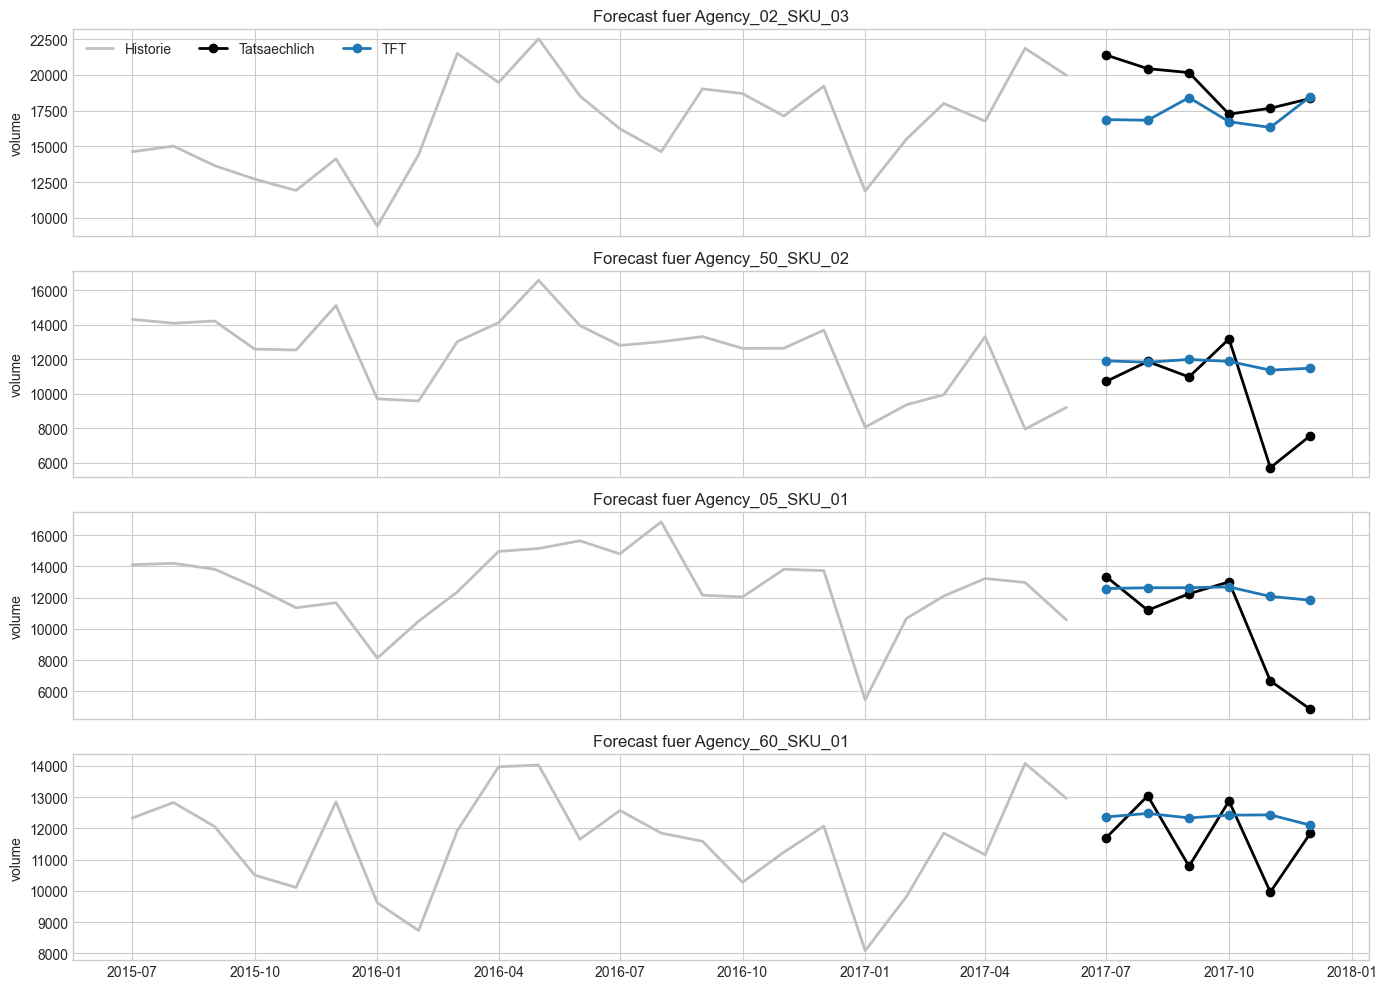

,model,scope,MAE,RMSE,MAPE_%
0,Temporal Fusion Transformer,48 reale Reihen,1271.28,1728.44,19.22


In [7]:

fig, axes = plt.subplots(len(plot_series), 1, figsize=(14, 10), sharex=True)

for ax, series_id in zip(axes, plot_series):
    forecast_slice = results_df[results_df["series_id"] == series_id].sort_values("time_idx")
    history_start = int(forecast_slice["time_idx"].min()) - encoder_length
    history_slice = model_df[
        (model_df["series_id"] == series_id)
        & (model_df["time_idx"] >= history_start)
        & (model_df["time_idx"] < forecast_slice["time_idx"].min())
    ].sort_values("time_idx")

    ax.plot(history_slice["date"], history_slice["volume"], linewidth=2, color="0.75", label="Historie")
    ax.plot(forecast_slice["date"], forecast_slice["actual"], marker="o", linewidth=2, color="black", label="Tatsaechlich")
    ax.plot(forecast_slice["date"], forecast_slice["tft_forecast"], marker="o", linewidth=2, color="tab:blue", label="TFT")
    ax.set_title(f"Forecast fuer {series_id}")
    ax.set_ylabel("volume")

axes[0].legend(ncol=3, loc="upper left")
plt.tight_layout()
plt.show()

metric_df


## Interpretation des TFT

Der Temporal Fusion Transformer liefert nicht nur Prognosen, sondern auch **aggregierte Interpretationen** ueber den Validierungssplit:

- **Attention**: auf welche vergangenen Zeitpunkte der Decoder fuer den Forecast schaut
- **Variable Selection Weights**: welche statischen, Encoder- und Decoder-Variablen der TFT besonders stark nutzt

Wichtig: Diese Gewichte sind **Importances**, keine linearen Regressionskoeffizienten. Sie zeigen also relative Wichtigkeit im Modell, nicht direkte Wirkungsrichtungen.

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


GPU available: True (mps), used: False


TPU available: False, using: 0 TPU cores


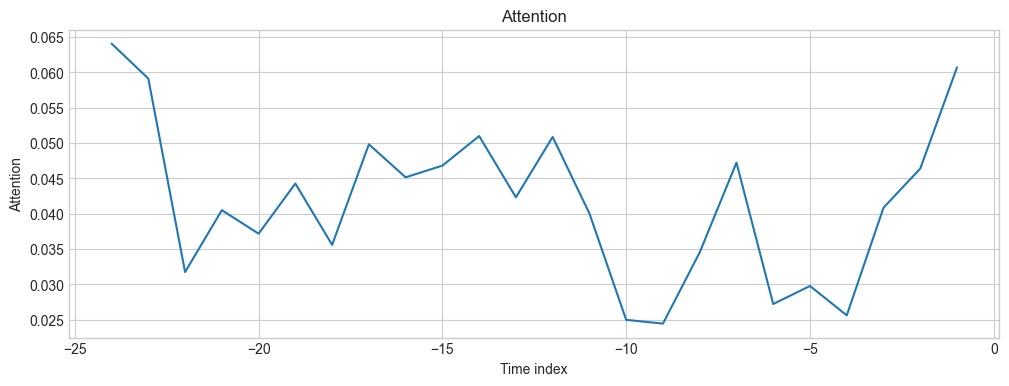

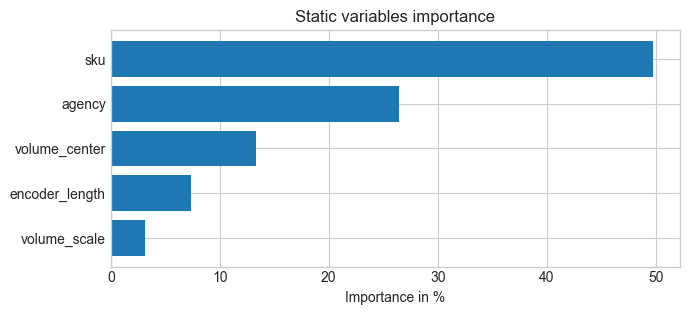

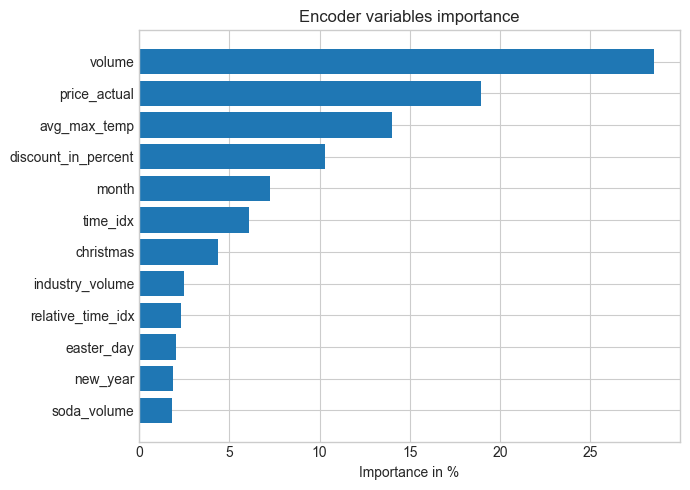

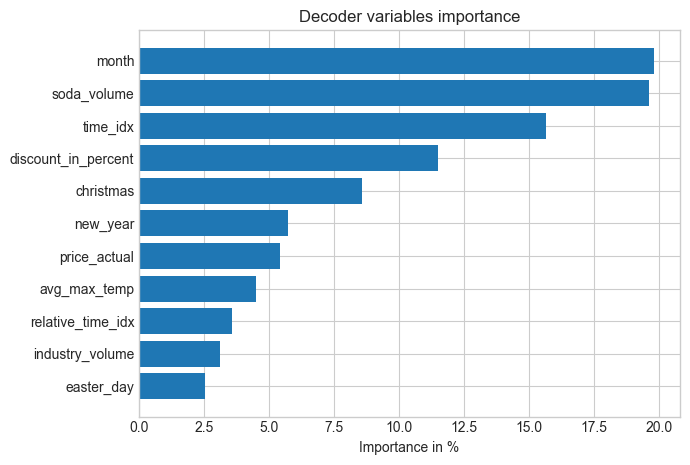

,block,variable,importance_%
0,static,sku,49.75
1,static,agency,26.48
2,static,volume_center,13.28
3,static,encoder_length,7.32
4,static,volume_scale,3.17
5,encoder,volume,28.56
6,encoder,price_actual,18.96
7,encoder,avg_max_temp,14.02
8,encoder,discount_in_percent,10.28
9,encoder,month,7.24


In [8]:
raw_prediction_output = tft.predict(
    val_tft_loader,
    mode="raw",
    trainer_kwargs={"accelerator": "cpu", "devices": 1},
    return_index=True,
)

interpretation = tft.interpret_output(raw_prediction_output.output, reduction="sum")
interpretation_figs = tft.plot_interpretation(interpretation)

for plot_name in ["attention", "static_variables", "encoder_variables", "decoder_variables"]:
    display(interpretation_figs[plot_name])
    plt.close(interpretation_figs[plot_name])


def importance_table(values, labels, block_name):
    weights = values.detach().cpu().numpy().astype(float)
    weights = weights / weights.sum()
    return pd.DataFrame(
        {
            "block": block_name,
            "variable": list(labels),
            "importance_%": np.round(weights * 100, 2),
        }
    ).sort_values("importance_%", ascending=False)


importance_df = pd.concat(
    [
        importance_table(interpretation["static_variables"], tft.static_variables, "static"),
        importance_table(interpretation["encoder_variables"], tft.encoder_variables, "encoder"),
        importance_table(interpretation["decoder_variables"], tft.decoder_variables, "decoder"),
    ],
    ignore_index=True,
)
importance_df

## Zusammenfassung

- Das Notebook zeigt jetzt nur noch die fuer TFT relevanten Schritte.
- `get_stallion_data()` bleibt erhalten und liefert genau den Typ von Business-Kovariaten, fuer den TFT gedacht ist.
- Gegenueber dem alten Mini-Setup trainiert der TFT jetzt auf deutlich mehr parallelen Reihen und nicht nur implizit in einem Mischvergleich.
- Zusaetzlich zeigt das Notebook jetzt die eingebauten TFT-Interpretationen fuer Attention und Variable Selection Weights.